# Assignment 1: Monte Carlo Pricing and Convergence under the Risk-Neutral Measure

## Introduction

**Objective:**
The primary objective of this assignment is to establish a robust, frictionless pricing engine for European options using Monte Carlo simulation. Before introducing market frictions such as transaction costs into delta hedging strategies, we must first mathematically and computationally verify the foundational pricing baseline under the risk-neutral measure $\mathbb{Q}$. 

**Methodology:**
According to the Fundamental Theorem of Asset Pricing, the arbitrage-free price of a derivative is the discounted expected value of its terminal payoff under the risk-neutral measure. We will simulate the terminal distribution of the underlying asset using the exact solution to the Geometric Brownian Motion (GBM) stochastic differential equation (SDE). By generating a large sample of terminal stock paths, we compute the Monte Carlo estimator for the option premium. Finally, we will rigorously benchmark this empirical estimator against the analytical Black-Scholes-Merton (BSM) closed-form solution and verify the theoretical $\mathcal{O}(N^{-1/2})$ convergence rate of the standard error.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set plotting style for professional documentation
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = (8, 5)

## Part (a): Simulation of Terminal Prices

Under the risk-neutral measure $\mathbb{Q}$, the asset price dynamics follow the SDE:
$$dS_t = r S_t dt + \sigma S_t dW_t^{\mathbb{Q}}$$
where $r$ is the risk-free rate, $\sigma$ is the volatility, and $W_t^{\mathbb{Q}}$ is a standard Brownian motion under $\mathbb{Q}$.

By applying Ito's Lemma to $\ln(S_t)$, we obtain the exact closed-form solution for the terminal stock price at maturity $T$:
$$S_T = S_0 \exp\left( \left( r - \frac{\sigma^2}{2} \right)T + \sigma W_T^{\mathbb{Q}} \right)$$

Since we only require the terminal distribution (and not the path-dependent evolution), time-stepping is unnecessary. We can directly sample the terminal Brownian motion as $W_T^{\mathbb{Q}} \sim \mathcal{N}(0, T)$, which is computationally equivalent to sampling $Z \sim \mathcal{N}(0, 1)$ and scaling by $\sqrt{T}$.

**Parameters:**
* Initial Stock Price ($S_0$): $100$
* Strike Price ($K$): $100$
* Risk-Free Rate ($r$): $0.05$
* Volatility ($\sigma$): $0.2$
* Time to Maturity ($T$): $1.0$ year
* Number of Paths ($N$): $10^5$

In [6]:
# System Parameters
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0
N_paths = 10**5

# Set random seed for reproducibility
np.random.seed(42)

# Sample standard normal variables Z ~ N(0, 1)
Z = np.random.standard_normal(N_paths)

# Scale to get WT ~ N(0, T)
WT = np.sqrt(T) * Z

# Compute exact terminal stock prices (vectorized)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * WT)

### Visual Verification: Terminal Stock Distribution

To verify the integrity of our geometric Brownian motion simulation, we plot the empirical distribution of the simulated terminal stock prices against the theoretical log-normal probability density function. For a log-normally distributed random variable $S_T$, the theoretical PDF is given by:
$$f(x) = \frac{1}{x \sigma \sqrt{2\pi T}} \exp\left( -\frac{(\ln(x) - \mu)^2}{2\sigma^2 T} \right)$$
where $\mu = \ln(S_0) + (r - \sigma^2/2)T$.

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hr/wtrtcw5n5y7gysy7xljmy7f80000gn/T/ipykernel_41807/4136501173.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Distribution of Terminal Stock Price $S_T$ under $\mathbb{Q}$', fontsize=14, fontweight='bold')


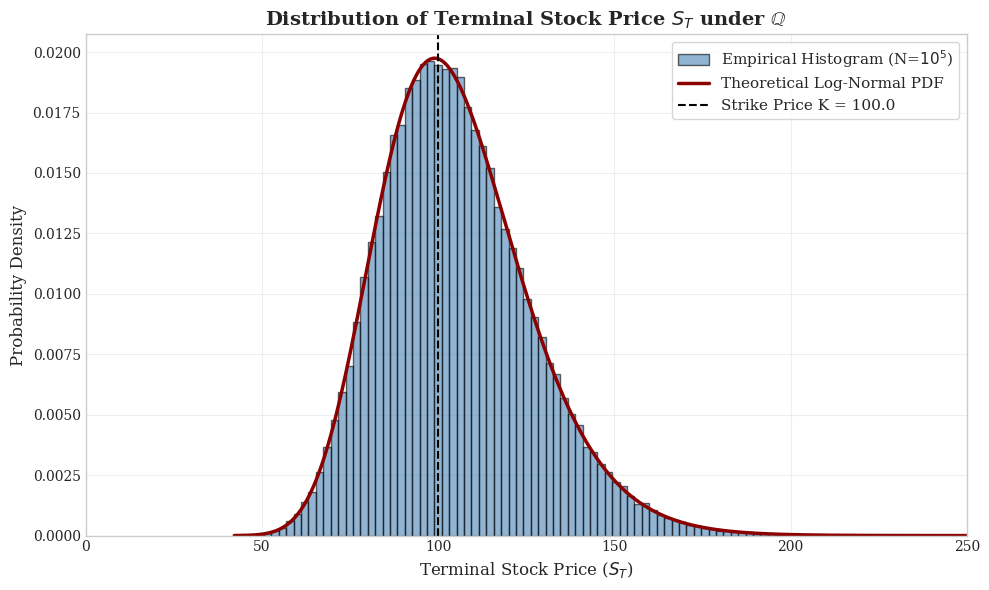

In [7]:
# Extract parameters for the theoretical log-normal PDF
mu_log = np.log(S0) + (r - 0.5 * sigma**2) * T
std_log = sigma * np.sqrt(T)

# Create an array of x values for the theoretical curve
x_vals = np.linspace(np.min(ST), np.max(ST), 500)
# Theoretical PDF
pdf_theoretical = (1 / (x_vals * std_log * np.sqrt(2 * np.pi))) * \
                  np.exp(- (np.log(x_vals) - mu_log)**2 / (2 * std_log**2))

# Plotting
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Empirical Histogram (N=$10^5$)')
plt.plot(x_vals, pdf_theoretical, color='darkred', linewidth=2.5, label='Theoretical Log-Normal PDF')

plt.title('Distribution of Terminal Stock Price $S_T$ under $\mathbb{Q}$', fontsize=14, fontweight='bold')
plt.xlabel('Terminal Stock Price ($S_T$)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.axvline(x=K, color='black', linestyle='--', linewidth=1.5, label=f'Strike Price K = {K}')
plt.legend(frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 250) # Trim extreme right tail for better visibility
plt.tight_layout()
plt.show()

## Part (b): Monte Carlo Estimator and Standard Error

The arbitrage-free price of the European call option is given by the discounted expectation:
$$C_0 = e^{-rT} \mathbb{E}^{\mathbb{Q}}[\max(S_T - K, 0)]$$

We approximate this expectation using the sample mean of the simulated payoffs:
$$\hat{C}_0 = e^{-rT} \frac{1}{N} \sum_{i=1}^{N} \max(S_T^{(i)} - K, 0)$$

To quantify the uncertainty of our estimator, we compute the Standard Error of the Mean (SEM). Let $P^{(i)} = e^{-rT}\max(S_T^{(i)} - K, 0)$ be the discounted payoff for the $i$-th path. The standard error is:
$$\text{SE} = \frac{s_P}{\sqrt{N}}$$
where $s_P$ is the sample standard deviation of the simulated discounted payoffs.

In [8]:
# Compute discounted payoffs for all paths
discount_factor = np.exp(-r * T)
payoffs = np.maximum(ST - K, 0)
discounted_payoffs = discount_factor * payoffs

# Compute Monte Carlo Estimator (Sample Mean)
C0_hat = np.mean(discounted_payoffs)

# Compute Sample Standard Deviation and Standard Error
sample_std = np.std(discounted_payoffs, ddof=1)
SE = sample_std / np.sqrt(N_paths)

print(f"Monte Carlo Estimate (C0_hat): {C0_hat:.4f}")
print(f"Standard Error (SE): {SE:.4f}")

Monte Carlo Estimate (C0_hat): 10.4739
Standard Error (SE): 0.0466


## Part (c): Benchmarking against Black-Scholes Closed-Form

To validate our simulation engine, we compare the empirical estimate $\hat{C}_0$ against the theoretical Black-Scholes formula:
$$C_{\text{BS}} = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2)$$
where $\Phi(\cdot)$ is the cumulative distribution function of the standard normal distribution, and:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma \sqrt{T}$$

By the Central Limit Theorem, approximately $95\%$ of our Monte Carlo estimates should fall within $\pm 1.96$ standard errors of the true theoretical mean. We verify this agreement below.

In [10]:
# Compute Black-Scholes Closed-Form Solution
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

C_BS = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Compute deviation in terms of standard errors
error = np.abs(C0_hat - C_BS)
se_deviation = error / SE

print(f"Black-Scholes Exact Price: {C_BS:.4f}")
print(f"Absolute Error: {error:.4f}")
print(f"Deviation in Standard Errors: {se_deviation:.2f} SE")

if se_deviation <= 2.0:
    print("Conclusion: The MC estimate is in agreement with the closed-form solution (within ~2 SE).")
else:
    print("Conclusion: The MC estimate deviated by more than 2 SE. Consider checking the random seed or implementation.")

Black-Scholes Exact Price: 10.4506
Absolute Error: 0.0233
Deviation in Standard Errors: 0.50 SE
Conclusion: The MC estimate is in agreement with the closed-form solution (within ~2 SE).


### Visual Verification: Law of Large Numbers (LLN)

By the Strong Law of Large Numbers, the sample mean of the discounted payoffs almost surely converges to the true expected value as the number of paths $N \to \infty$. To visualize this, we plot the cumulative rolling average of our Monte Carlo estimator as the sample size grows, benchmarking it against the static Black-Scholes analytical price.

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
/var/folders/hr/wtrtcw5n5y7gysy7xljmy7f80000gn/T/ipykernel_41807/3908194986.py:13: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(path_indices[::step], rolling_means[::step], color='royalblue', alpha=0.8, label='Rolling MC Estimator $\hat{C}_0$')


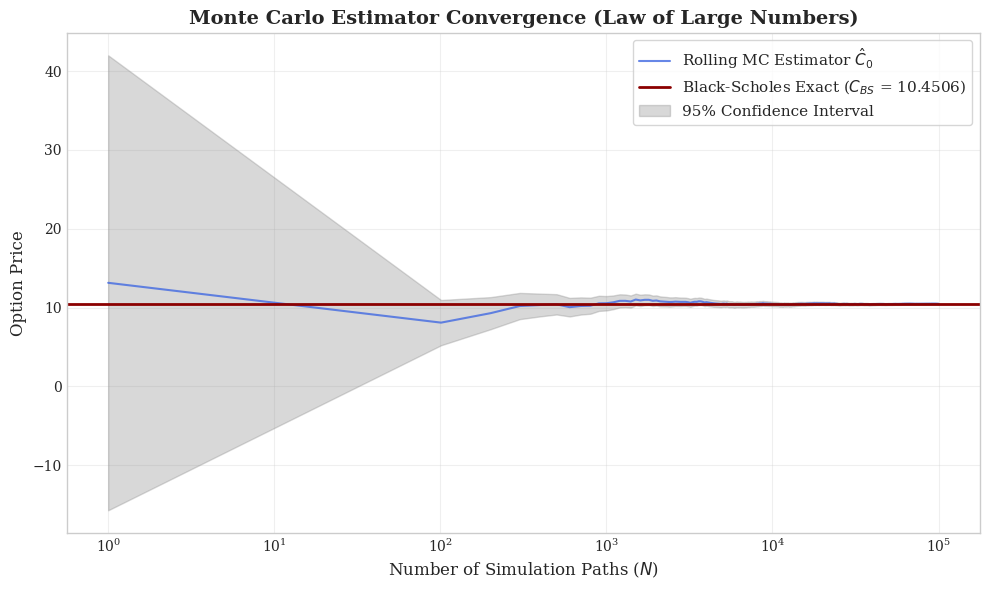

In [11]:
# Calculate the running cumulative mean of the simulated prices
# Note: For memory efficiency on large arrays, we compute this directly 
# rather than keeping all intermediate states in memory.
running_sums = np.cumsum(discounted_payoffs)
path_indices = np.arange(1, N_paths + 1)
rolling_means = running_sums / path_indices

# Plotting
plt.figure(figsize=(10, 6))

# Only plot every 100th point to speed up rendering without losing the visual shape
step = 100 
plt.plot(path_indices[::step], rolling_means[::step], color='royalblue', alpha=0.8, label='Rolling MC Estimator $\hat{C}_0$')
plt.axhline(y=C_BS, color='darkred', linestyle='-', linewidth=2, label=f'Black-Scholes Exact ($C_{{BS}}$ = {C_BS:.4f})')

# Add standard error confidence bounds
plt.fill_between(path_indices[::step], 
                 (rolling_means - 1.96 * (sample_std / np.sqrt(path_indices)))[::step], 
                 (rolling_means + 1.96 * (sample_std / np.sqrt(path_indices)))[::step], 
                 color='gray', alpha=0.3, label='95% Confidence Interval')

plt.title('Monte Carlo Estimator Convergence (Law of Large Numbers)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Simulation Paths ($N$)', fontsize=12)
plt.ylabel('Option Price', fontsize=12)
plt.xscale('log') # Log scale for the X-axis shows the early volatility and later stabilization clearly
plt.legend(frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part (d): Convergence Analysis

Theoretical properties of the Monte Carlo method dictate that the standard error decays at a rate proportional to $N^{-1/2}$. Mathematically, this implies:
$$\text{SE}(N) \propto \frac{1}{\sqrt{N}}$$

Taking the natural logarithm of both sides yields a linear relationship:
$$\ln(\text{SE}) = -\frac{1}{2}\ln(N) + C$$

By plotting the empirical standard error against the number of simulation paths $N$ on a log-log scale, we should observe a straight line with a slope of exactly $-0.5$. This formally verifies that the implementation is behaving according to the Central Limit Theorem.

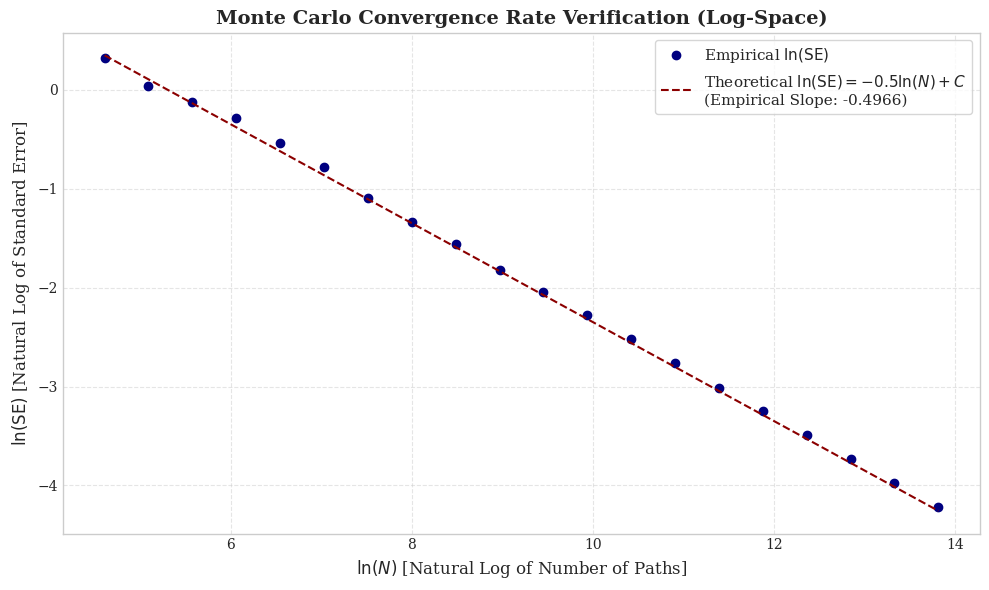

Empirical convergence slope: -0.4966
Expected theoretical slope: -0.5000


In [21]:
# Define an array of path counts spaced logarithmically
N_values = np.logspace(2, 6, num=20, dtype=int)
empirical_SEs = []

for n in N_values:
    # Generate fresh arrays to ensure complete independence for rigor
    z_n = np.random.standard_normal(n)
    ST_n = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z_n)
    payoffs_n = discount_factor * np.maximum(ST_n - K, 0)
    
    se_n = np.std(payoffs_n, ddof=1) / np.sqrt(n)
    empirical_SEs.append(se_n)

# Perform linear regression on the log-transformed data to extract the empirical slope
log_N = np.log(N_values)
log_SE = np.log(empirical_SEs)
slope, intercept = np.polyfit(log_N, log_SE, 1)

# Plotting
plt.figure(figsize=(10, 6))

# Plot the explicitly log-transformed data on standard linear axes
# Using raw strings (r"...") to prevent Python from misinterpreting LaTeX backslashes
plt.plot(log_N, log_SE, marker='o', linestyle='none', color='navy', 
         label=r'Empirical $\ln(\mathrm{SE})$')

# Plot the theoretical reference line in log-space: ln(SE) = -0.5 * ln(N) + C
log_theoretical_SEs = -0.5 * log_N + intercept
theoretical_label = (r'Theoretical $\ln(\mathrm{SE}) = -0.5 \ln(N) + C$' + 
                     f'\n(Empirical Slope: {slope:.4f})')
plt.plot(log_N, log_theoretical_SEs, linestyle='--', color='darkred', label=theoretical_label)

plt.title('Monte Carlo Convergence Rate Verification (Log-Space)', fontsize=14, fontweight='bold')

# Correctly label the axes using raw strings and proper math environments
plt.xlabel(r'$\ln(N)$ [Natural Log of Number of Paths]', fontsize=12)
plt.ylabel(r'$\ln(\mathrm{SE})$ [Natural Log of Standard Error]', fontsize=12)

plt.legend(frameon=True, fontsize=11)
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Empirical convergence slope: {slope:.4f}")
print(f"Expected theoretical slope: -0.5000")